In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/online_news_cleaned.csv")

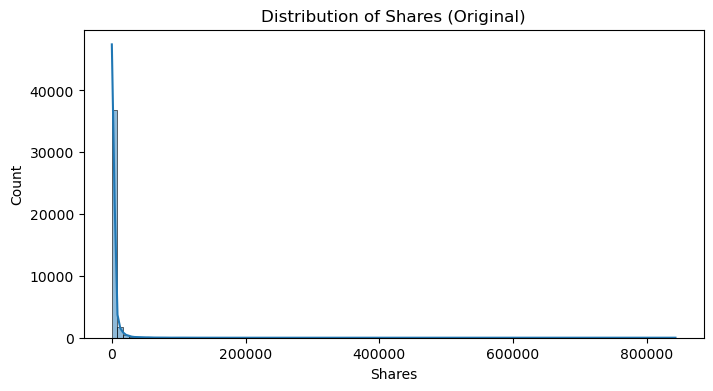

In [35]:
plt.figure(figsize=(8,4))
sns.histplot(df["shares"], bins=100, kde=True)
plt.title("Distribution of Shares (Original)")
plt.xlabel("Shares")
plt.show()

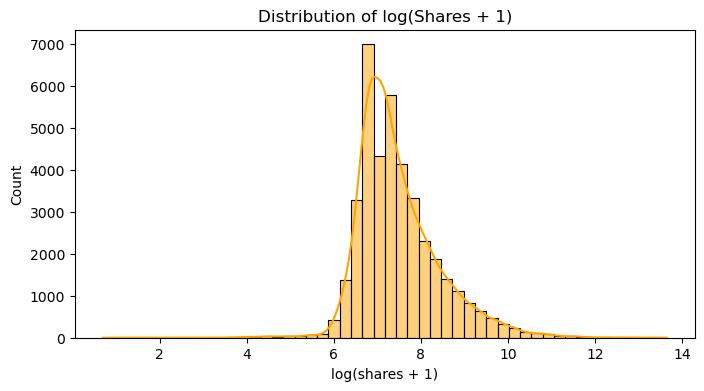

In [36]:
plt.figure(figsize=(8,4))
sns.histplot(df["log_shares"], bins=50, kde=True, color="orange")
plt.title("Distribution of log(Shares + 1)")
plt.xlabel("log(shares + 1)")
plt.show()

Raw shares distribution is extremely right-skewed. Log-transform stabilizes variance and improves regression performance.

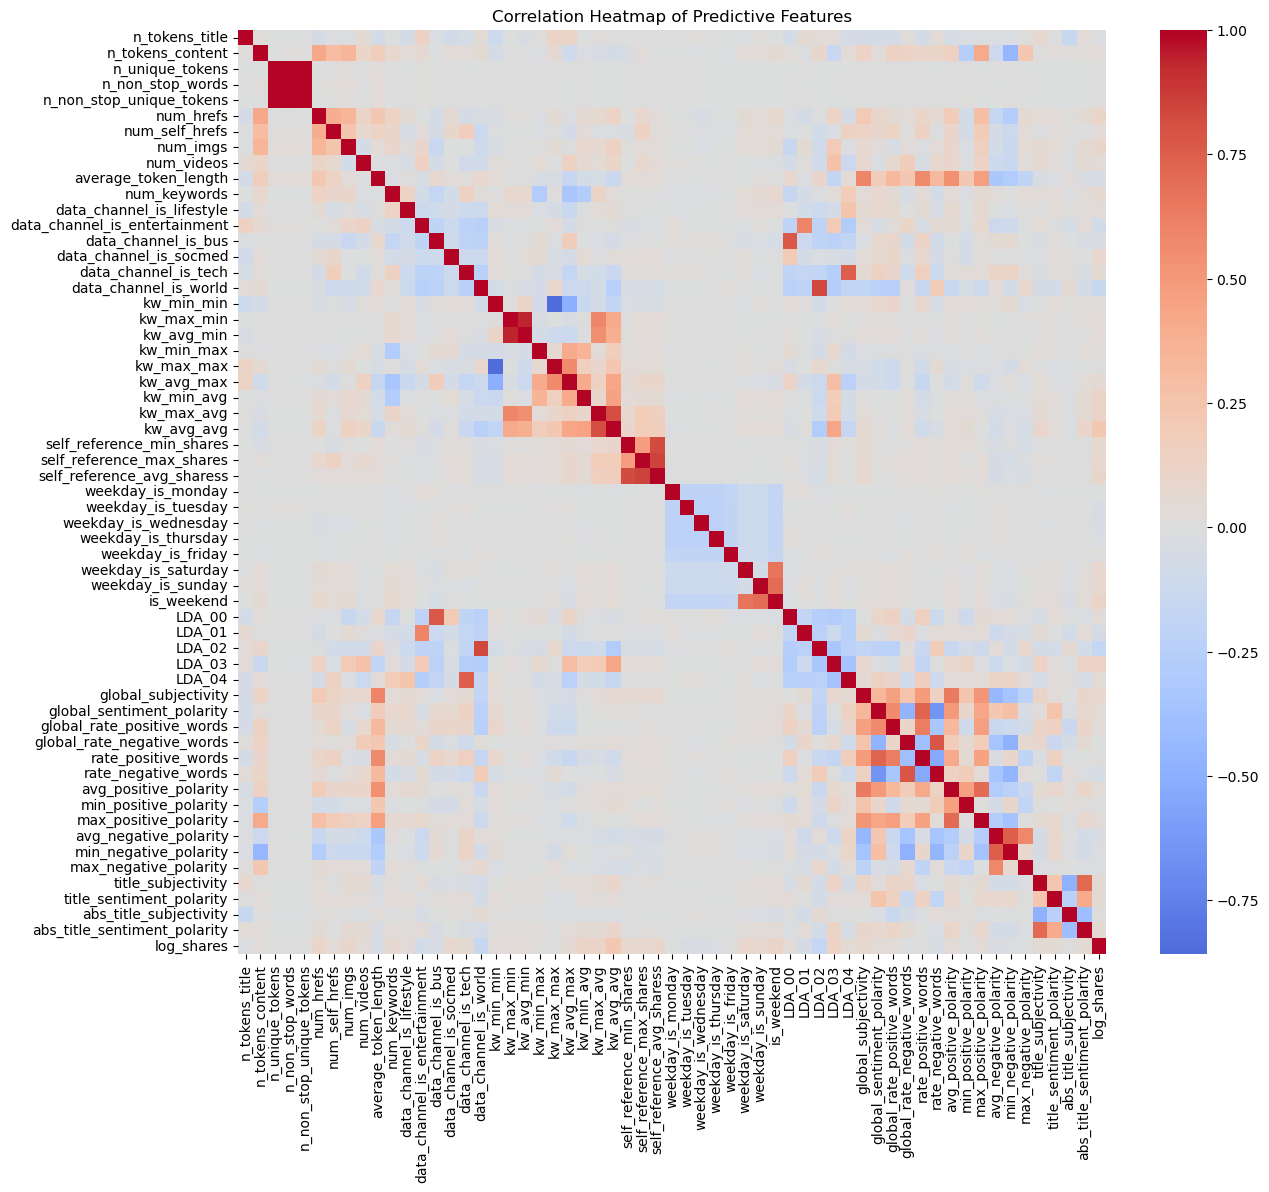

In [37]:
plt.figure(figsize=(14,12))
corr = df.drop(columns=["shares"]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Predictive Features")
plt.show()

The correlation structure of the dataset suggests a noisy, high-dimensional prediction problem with limited linear relationships.

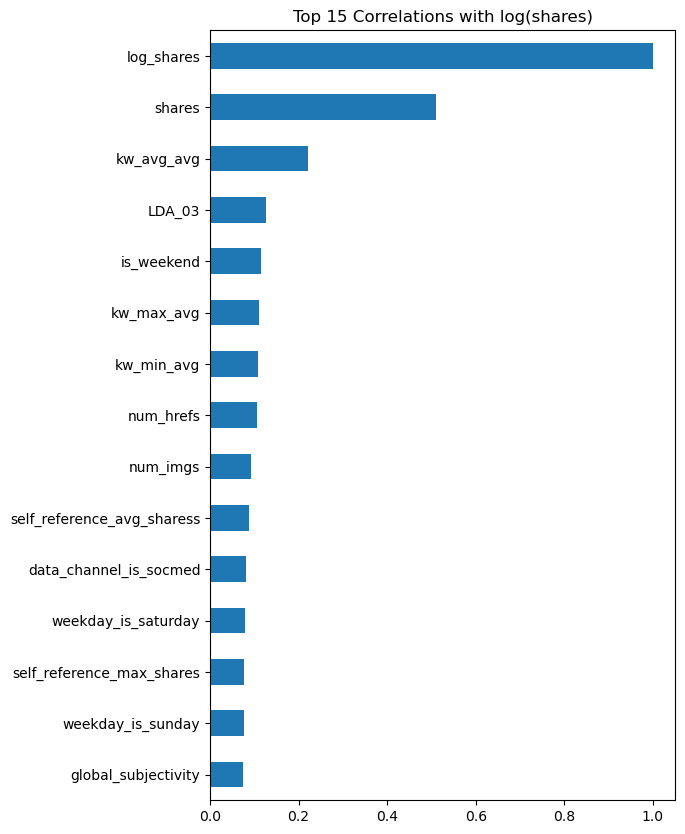

In [38]:
target_corr = df.corr()["log_shares"].sort_values(ascending=False)
plt.figure(figsize=(6,10))
target_corr.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 15 Correlations with log(shares)")
plt.show()

Overall, the extremely low correlations across all predictors demonstrate that no single feature strongly explains article popularity. This reinforces the need for regularized models (Ridge/Lasso) that can handle weak, noisy signals spread across many features.

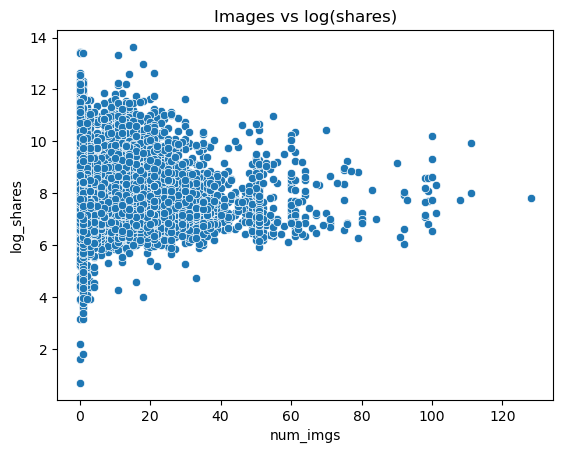

In [39]:
sns.scatterplot(x=df["num_imgs"], y=df["log_shares"])
plt.title("Images vs log(shares)")
plt.show()

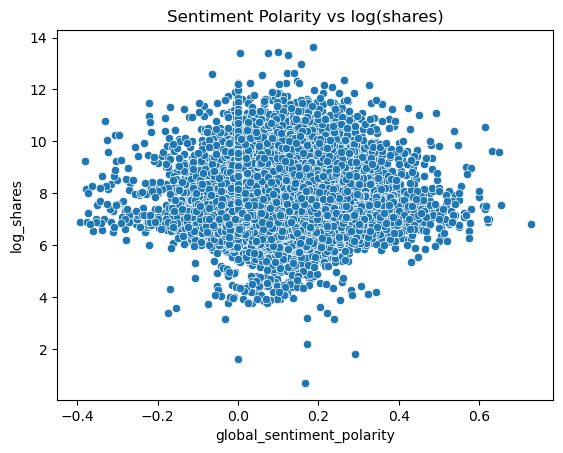

In [40]:
sns.scatterplot(x=df["global_sentiment_polarity"], y=df["log_shares"])
plt.title("Sentiment Polarity vs log(shares)")
plt.show()

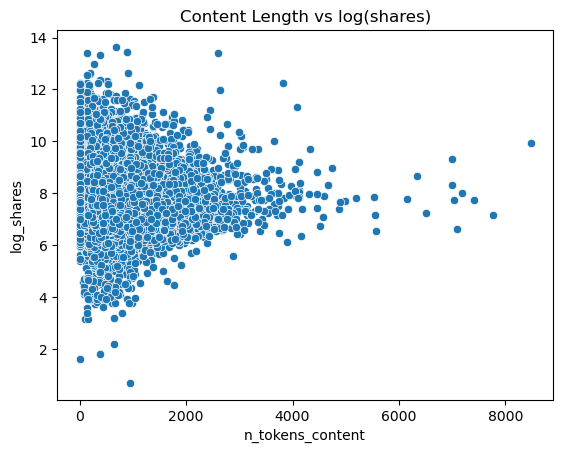

In [41]:
sns.scatterplot(x=df["n_tokens_content"], y=df["log_shares"])
plt.title("Content Length vs log(shares)")
plt.show()

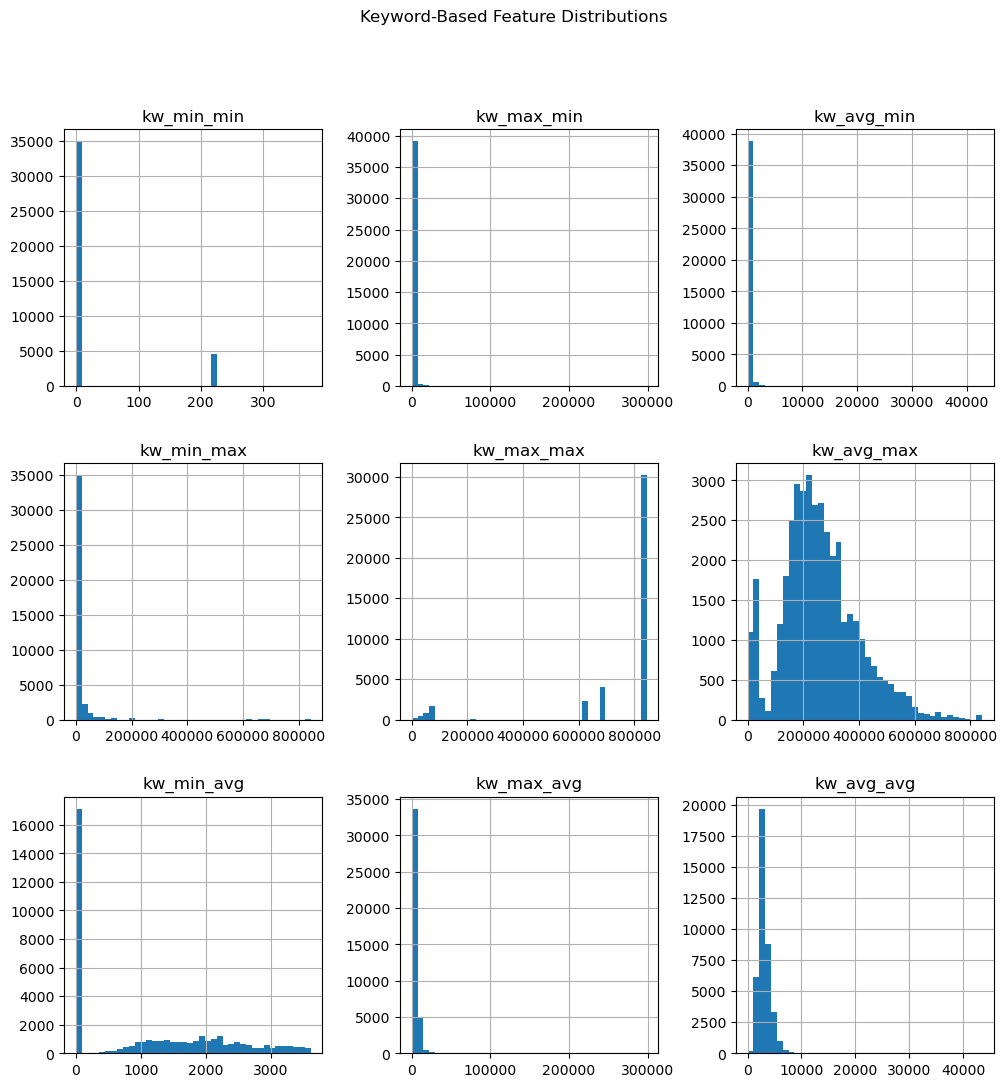

In [42]:
kw_cols = [c for c in df.columns if c.startswith("kw_")]
df[kw_cols].hist(figsize=(12,12), bins=40)
plt.suptitle("Keyword-Based Feature Distributions")
plt.show()

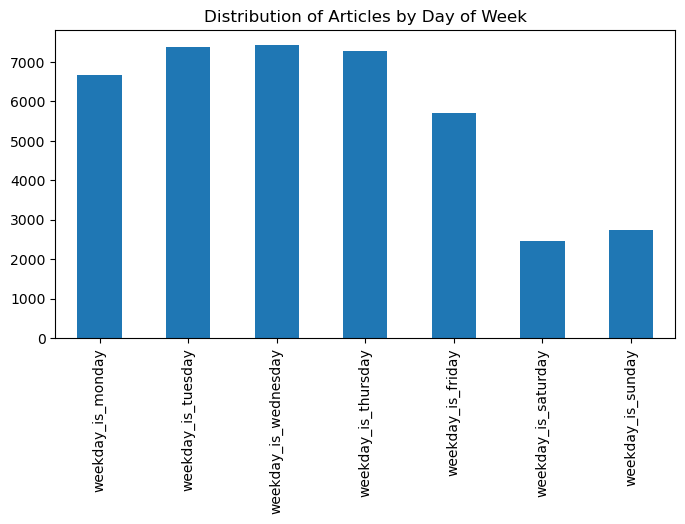

In [43]:
weekday_cols = [c for c in df.columns if c.startswith("weekday_is_")]
df[weekday_cols].sum().plot(kind="bar", figsize=(8,4))
plt.title("Distribution of Articles by Day of Week")
plt.show()

Keyword-based features exhibit high skew, extreme outliers, and large variance, indicating that keyword performance is extremely uneven across articles.

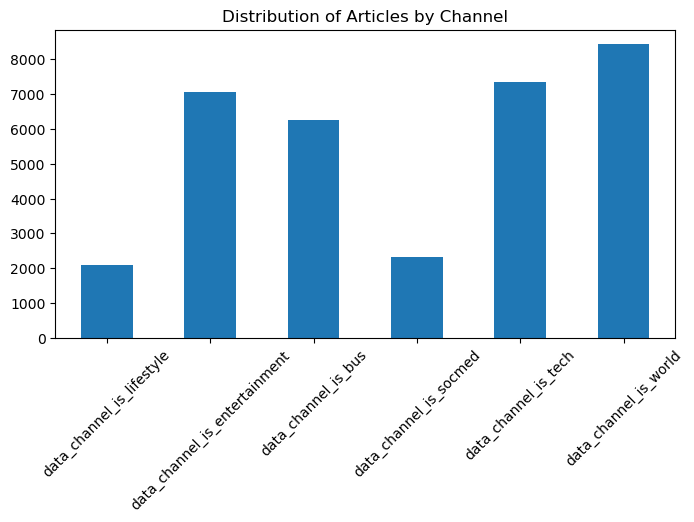

In [ ]:
channel_cols = [c for c in df.columns if "data_channel" in c]

df[channel_cols].sum().plot(kind="bar", figsize=(8,4))
plt.title("Distribution of Articles by Channel")
plt.xticks(rotation=45)
plt.show()

## Summary
The dataset contains 39,644 articles and 58 numeric features related to content structure, keywords, sentiment, topics, and publication timing. There are no missing values, and all columns are in a modeling-friendly format.

The target variable shares is extremely right-skewed, so using the log-transformed version (log_shares) gives a more stable distribution for regression.

Most features show very high variance and strong skew, especially keyword-based variables, which contain extreme outliers. This confirms the need for scaling and regularization.

Correlation analysis shows that no single feature strongly predicts popularity. All correlations with log_shares are weak (mostly under 0.15).

Distribution plots of weekday and channel variables reveal that Mashable publishes far more articles on weekdays and in certain categories (World, Tech, Entertainment), but these patterns do not translate into meaningful predictive power.

Overall, the dataset is high-dimensional and noisy, with many weak predictors rather than a few strong ones. The best modeling approach will require standardization, regularization (Ridge/Lasso), and careful validation to avoid overfitting.